# 次元削減（Dimensionality Reduction） - PCA

高次元データを低次元に圧縮して可視化・前処理に活用します。  
ここでは **PCA（主成分分析）** を使います。

| ステップ | 内容 |
|----------|------|
| 1 | データの読み込み |
| 2 | PCA で 2次元に圧縮 |
| 3 | 寄与率の確認 |
| 4 | 可視化 |
| 5 | PCA を前処理として分類に活用 |

## 1. データの読み込み

In [1]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
import pandas as pd

iris = load_iris()
X = iris.data   # 4次元
y = iris.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("元データの次元数:", X.shape[1])  # 4次元

元データの次元数: 4


## 2. PCA で 2次元に圧縮

In [2]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("圧縮後の次元数:", X_pca.shape[1])  # 2次元

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['species'] = [iris.target_names[i] for i in y]
df_pca.head()

圧縮後の次元数: 2


,PC1,PC2,species
0,-2.264703,0.480027,setosa
1,-2.080961,-0.674134,setosa
2,-2.364229,-0.341908,setosa
3,-2.299384,-0.597395,setosa
4,-2.389842,0.646835,setosa


## 3. 寄与率の確認

各主成分がデータの情報をどれだけ保持しているかを示します。

各成分の寄与率: ['0.730', '0.229', '0.037', '0.005']
累積寄与率    : ['0.730', '0.958', '0.995', '1.000']


/tmp/ipykernel_15537/3051157169.py:22: UserWarning: Glyph 20027 (\N{CJK UNIFIED IDEOGRAPH-4E3B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15537/3051157169.py:22: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15537/3051157169.py:22: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15537/3051157169.py:22: UserWarning: Glyph 23492 (\N{CJK UNIFIED IDEOGRAPH-5BC4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15537/3051157169.py:22: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15537/3051157169.py:22: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15537/3051157169.py:22: UserWarning: Glyph 32047 (\N{CJK UNIFIED IDEOGRAP

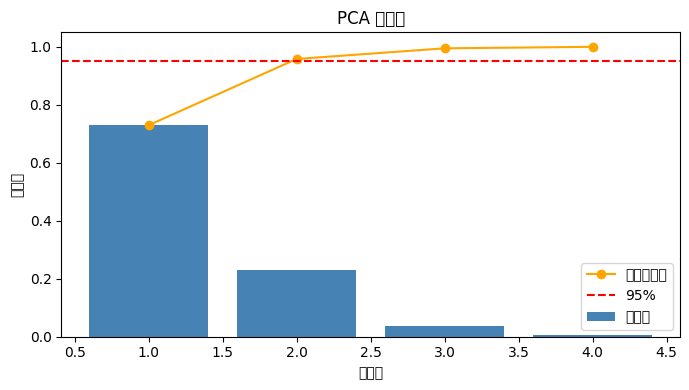

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 全成分の寄与率
pca_full = PCA(n_components=4)
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

print("各成分の寄与率:", [f"{v:.3f}" for v in explained])
print("累積寄与率    :", [f"{v:.3f}" for v in cumulative])

plt.figure(figsize=(7, 4))
plt.bar(range(1, 5), explained, label='寄与率', color='steelblue')
plt.plot(range(1, 5), cumulative, marker='o', color='orange', label='累積寄与率')
plt.axhline(0.95, color='red', linestyle='--', label='95%')
plt.xlabel("主成分")
plt.ylabel("寄与率")
plt.title("PCA 寄与率")
plt.legend()
plt.tight_layout()
plt.show()

## 4. 可視化（4次元 → 2次元）

/tmp/ipykernel_15537/110932174.py:13: UserWarning: Glyph 23492 (\N{CJK UNIFIED IDEOGRAPH-5BC4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15537/110932174.py:13: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15537/110932174.py:13: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15537/110932174.py:13: UserWarning: Glyph 12395 (\N{HIRAGANA LETTER NI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15537/110932174.py:13: UserWarning: Glyph 12424 (\N{HIRAGANA LETTER YO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15537/110932174.py:13: UserWarning: Glyph 12427 (\N{HIRAGANA LETTER RU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15537/110932174.py:13: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) D

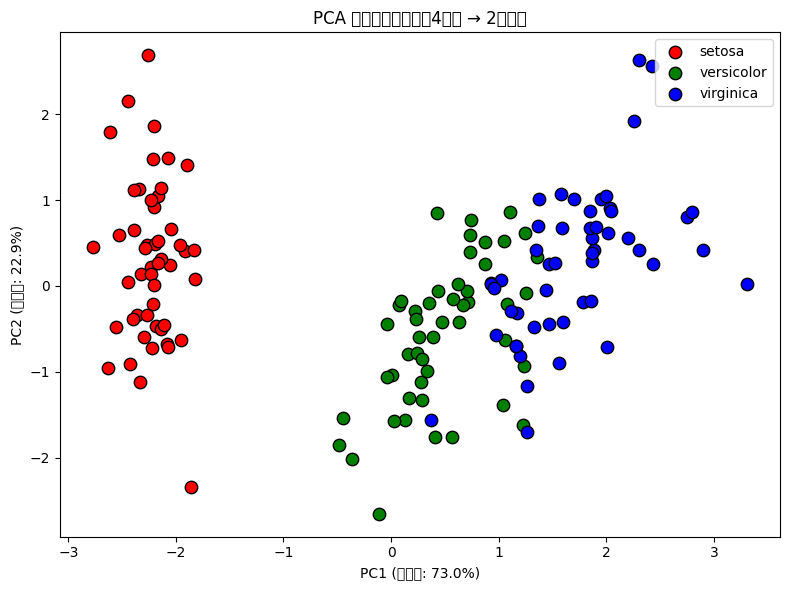

In [4]:
colors = ['red', 'green', 'blue']

plt.figure(figsize=(8, 6))
for i, color in enumerate(colors):
    idx = np.where(y == i)
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1],
                color=color, label=iris.target_names[i], edgecolors='k', s=80)

plt.xlabel(f"PC1 (寄与率: {explained[0]:.1%})")
plt.ylabel(f"PC2 (寄与率: {explained[1]:.1%})")
plt.title("PCA による次元削減（4次元 → 2次元）")
plt.legend()
plt.tight_layout()
plt.show()

## 5. PCA を前処理として分類に活用

次元削減したデータで分類モデルを学習し、元データと精度を比較します。

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 元データ（4次元）での精度
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)
acc_orig = accuracy_score(y_test, model.predict(X_test))

# PCA後（2次元）での精度
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_pca, y, test_size=0.2, random_state=42)
model2 = KNeighborsClassifier(n_neighbors=3)
model2.fit(X_train2, y_train2)
acc_pca = accuracy_score(y_test2, model2.predict(X_test2))

print(f"元データ（4次元）の正解率: {acc_orig:.4f}")
print(f"PCA後（2次元）の正解率  : {acc_pca:.4f}")
print(f"\n次元を半分に削減しても精度をほぼ維持できています")

元データ（4次元）の正解率: 1.0000
PCA後（2次元）の正解率  : 0.9333

次元を半分に削減しても精度をほぼ維持できています
